# Dedalus: 1D MWF

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import glob as glob
import h5py
import matplotlib.cm as cm
from importlib import import_module
import sys
sys.path.append('../')

In [71]:
plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.serif"] = "Times New Roman"

In [72]:
def sortKeyFunc(s):
    s = s.split('_')[-1] # s{num}.h5
    s = s[1:-3] #num
    return int(s)

def read_dedalus(folder,intype='snapshots'):
    if intype=='snapshots':
        data = []
        ss = sorted(glob.glob(folder+'/'+intype+'/'+intype+'*.h5'),key=sortKeyFunc)
        for file in ss:
            data.append(h5py.File(file,'r'))
    elif intype=='time_series':
        data = dict([])
        ss = sorted(glob.glob(folder+'/'+intype+'/'+intype+'*.h5'),key=sortKeyFunc)
        for ii,file in enumerate(ss):
            if ii==0:
                data['time'] = h5py.File(file,'r')['scales']['sim_time']
                data['timestep'] = h5py.File(file,'r')['scales']['iteration']
            else:
                data['time'] = np.hstack((data['time'],h5py.File(file,'r')['scales']['sim_time']))
                data['timestep'] = h5py.File(file,'r')['scales']['iteration']

        temp = h5py.File(ss[0],'r')
        tasks = list(temp['tasks'].keys())
        for task in tasks:
            for ii,file in enumerate(ss):
                if ii==0:
                    data[task] = h5py.File(file,'r')['tasks'][task][:,0]
                else:
                    data[task] = np.hstack((data[task],h5py.File(file,'r')['tasks'][task][:,0]))
        data['len_ss'] = len(ss)
    return data

def snapshot_slice(n,data,field):
    for ii,subdat in enumerate(data):
        if np.any(subdat['scales']['write_number'][:]==n):
            n_m = np.squeeze(np.where(subdat['scales']['write_number'][:]==n))
            s = ii
    return [s,n_m]

In [73]:
a_exp = 0.0
c1_exp = -1.0

# Calibrated using single band MWF mean, a_exp = 0, eps_exp = -1, nu_t_exp = 1.0 (Re_c = 72)
def nu_t(qe,C_t,Re):
    return C_t*qe*Re**(-c1_exp) + 1/Re
    
C_t = 0.05
a = 0.3
c1 = 0.144
b = 0.0

kappa = 0.045
kexp = 0.0
eta = 5e-3

alpha = 0.01
beta = np.pi/2

In [74]:
## Calibrated by MWF (newuq)
def A(q,a,eta,Re):
    return a*(Re/67)**(a_exp)*((q**2 + eta**2)**(1/2) - eta)

def B(q,b):
    return b*q

def eps(q,c1,Re):
    return c1*(Re/67)**(c1_exp)*q

In [75]:
## Calibrated by MWF (newuq)
def dA(qe,a,eta,Re):
    return a*(Re/67)**(a_exp)*qe*(qe**2 + eta**2)**(-1/2)

def dB(b):
    return b

def deps(qe,c1,Re):
    return c1*(Re/67)**(c1_exp)

In [76]:
# Define nullclines (for plotting)
def null_u(q,beta,eta,a,alpha,Re):
    return -beta*A(q,a,eta,Re)/(alpha+beta**2/Re) + 1 # u nullcline
def null_q(q,beta,eta,a,c1,alpha,Re): 
    return (2*alpha*q + eps(q,c1,Re))/(beta*A(q,a,eta,Re)/2)

In [77]:
c = c1*67
A_eq = lambda q0 : a*(np.sqrt(q0**2+eta**2)-eta)

def nul(q0,Re):
    return beta*A_eq(q0)*(alpha+beta**2/Re-beta*A_eq(q0))/2-(2*alpha+c/Re)*(alpha+beta**2/Re)*q0

## Load data

In [78]:
# Choose input directory
idir = './'

# Choose output directory
odir = './Figures/'

In [79]:
# Searches through all directories in 'Data' folder (which are named after experiments) and imports the data:
dirs = sorted(glob.glob(idir+'Lz256_Re80_IC68_minimal_v3d5'))

runs = []
Res = []
for file in dirs:
    run = file.split('/')[1]

    Re = run.split('_')[1].replace('d','.')[2:]
    Res.append(float(Re))
    runs.append(run)
    
Res = np.array(Res)
runs = np.array(runs)
argRes = Res.argsort()
Res = Res[argRes]
runs = runs[argRes]
Res = np.unique(Res)
print(runs)
print(Res)

['Lz256_Re80_IC68_minimal_v3d5']
[80.]


In [80]:
print (dirs)

['./Lz256_Re80_IC68_minimal_v3d5']


Let's import the data for each run now:

In [81]:
data = dict([])
for run in runs:
    data[run] = read_dedalus(idir+run)

Let's see what is in our imported variables.

We saved the data in what's called a 'dictionary', which names its variables with strings. To see the experiments do the following:

In [82]:
for run in runs:
    print(run)
    print(data[run])
    for subdat in data[run]:
        print(subdat['scales'].keys())
        print(subdat['tasks'].keys())
#         print(subdat['scales']['sim_time'][:])

Lz256_Re80_IC68_minimal_v3d5
[<HDF5 file "snapshots_s1.h5" (mode r)>]
<KeysViewHDF5 ['constant', 'iteration', 'kz', 'sim_time', 'timestep', 'wall_time', 'world_time', 'write_number', 'z']>
<KeysViewHDF5 ['q0', 'q1', 'u0', 'u1', 'v1', 'w1', 'zeta']>


In [83]:
data['Lz256_Re80_IC68_minimal_v3d5'][0].keys()

<KeysViewHDF5 ['scales', 'tasks']>

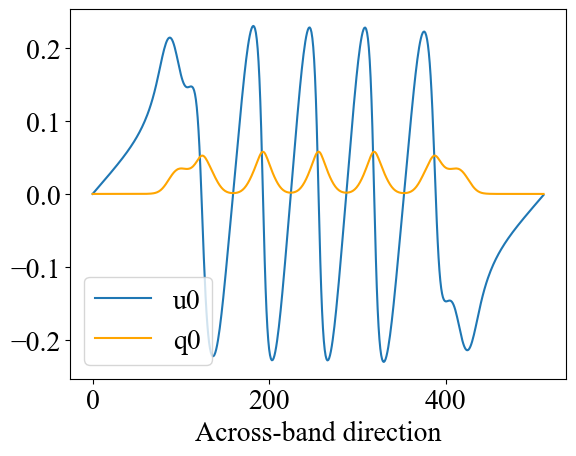

In [84]:
plt.plot((data['Lz256_Re80_IC68_minimal_v3d5'][0]['tasks']['u0'][()])[-1],label = 'u0')
plt.plot((data['Lz256_Re80_IC68_minimal_v3d5'][0]['tasks']['q0'][()])[-1], 'orange', label = 'q0')

plt.xlabel('Across-band direction')
plt.legend ()
plt.savefig(odir+'u0_vs_q0.png',dpi=150,bbox_inches='tight')
plt.show()



In [85]:
for run in data:
    print(run)

Lz256_Re80_IC68_minimal_v3d5


In [86]:
t_data = dict([])
for run in runs:
    try:
        t_data[run] = read_dedalus(idir+run,intype='time_series')
        print(run)
    except:
        t_data[run] = np.nan
        print(run,"NO DATA")

Lz256_Re80_IC68_minimal_v3d5


In [87]:
# params_data = dict([])
# for run in runs:
#     file = str(run+'/params').replace('/','.')
#     params = import_module(file)
#     params_data[run] = params

In [88]:
# p_data = dict([])
# for run in runs:
#     print(run)
#     p_data[run] = read_dedalus(idir+run,intype='profiles')

# Time series

In [89]:
for run in runs:
    print(run,t_data[run]['timestep'][-1],t_data[run]['time'][-1])

Lz256_Re80_IC68_minimal_v3d5 362816 20000.04308357447


Lz256_Re80_IC68_minimal_v3d5 80
total time 4770.263671875 total tsteps 97695


/var/folders/yt/llp6tnmn43jfqwk2w114dq080000gn/T/ipykernel_32553/1022095853.py:46: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1,figsize=(10,6))
/var/folders/yt/llp6tnmn43jfqwk2w114dq080000gn/T/ipykernel_32553/1022095853.py:58: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(2,figsize=(10,6))
/var/folders/yt/llp6tnmn43jfqwk2w114dq080000gn/T/ipykernel_32553/1022095853.py:70: UserWarning: Ignoring specified arguments in this call because figure with num: 3 already exists
  plt.figure(3,figsize=(10,6))


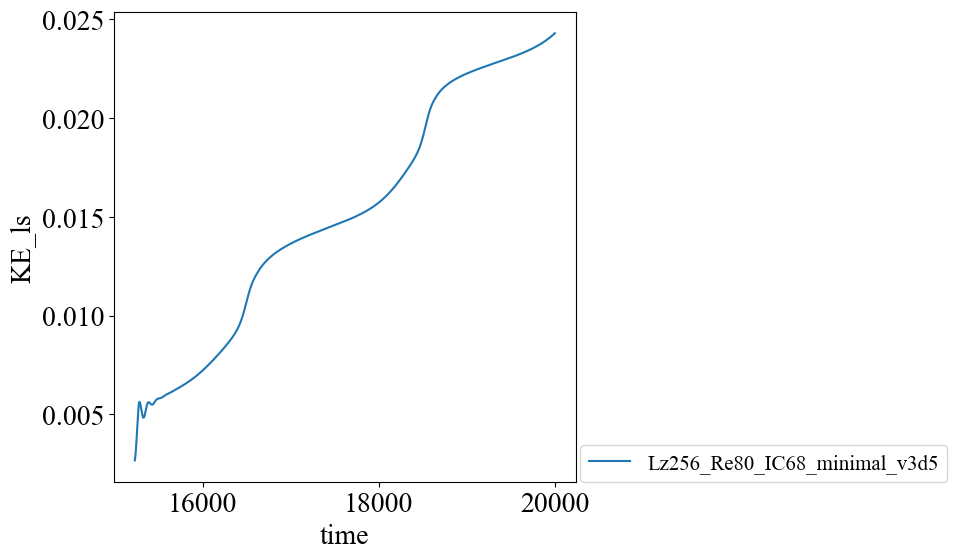

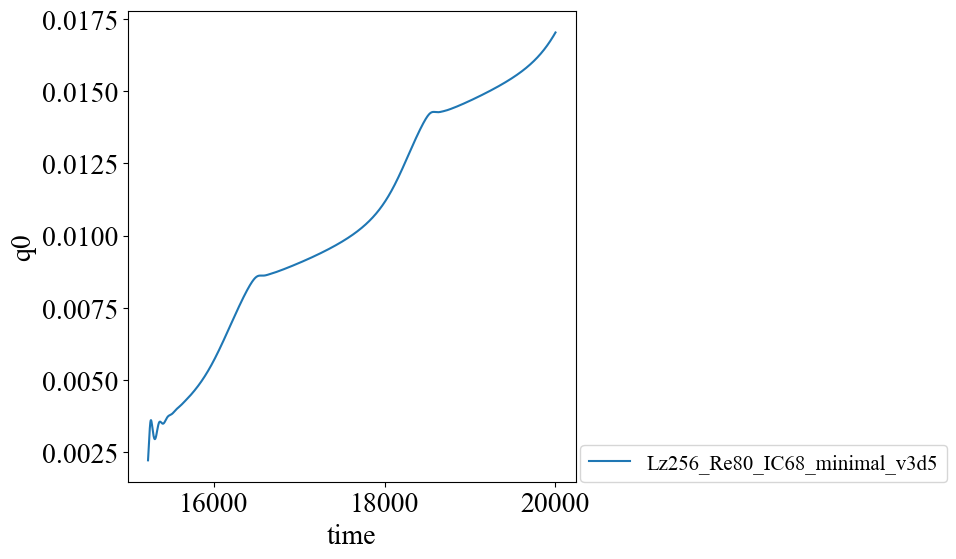

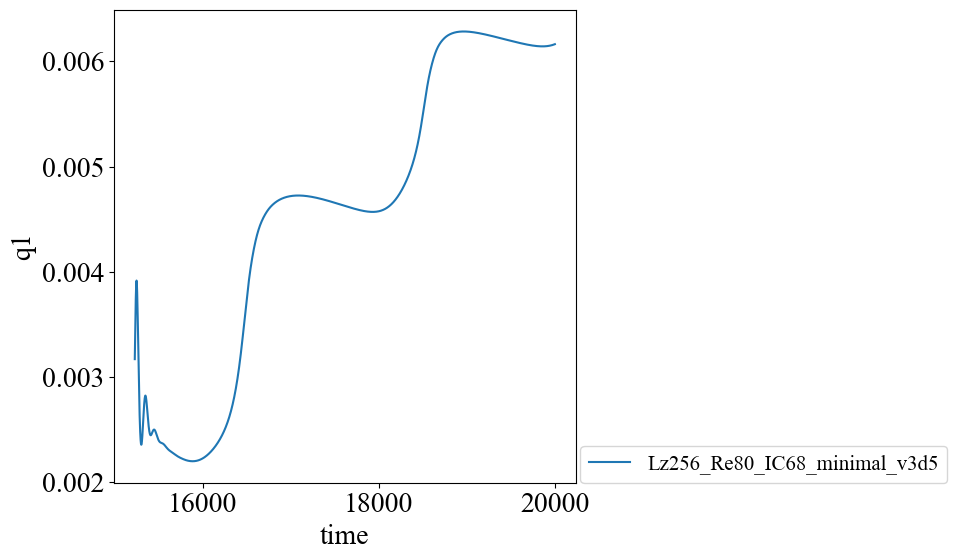

In [90]:
# Choose run
lw  = 2.5
alpha = 1
Res_temp = np.copy(Res)
q1s = []
for ii,run in enumerate(t_data): 
#     plt.figure(figsize=(8,6))
#     plt.title(run)
#     Re = float(run.split('_')[1][2:].replace('d','.'))
    # Re = params_data[run].Re
    Re = run.split('_')[1].replace('d','.')[2:]

#     if (Re>40)&(Re<90):
    print(run,Re)
    if 'res' in run:
        ls = '--'
        label='Re = %s' % int(Re)
    else:
        ls = '-'
        label= run
    time = t_data[run]['time'][:]
    KE = t_data[run]['en_ls'][:]
    print('total time',time[-1]-time[0],'total tsteps',t_data[run]['timestep'][-1]-t_data[run]['timestep'][0])
    plt.figure(1,figsize=(10,6))
    plt.plot(time,KE,marker='',label=run)#c=(0,0,(Re-np.min(Res))/(np.max(Res)-np.min(Res)),1),lw=lw,ls = ls,alpha=alpha,label=label)
    KE = t_data[run]['q0'][:]
    plt.figure(2,figsize=(10,6))
    plt.plot(time,KE,marker='',label=run)#c=((Re-np.min(Res))/(np.max(Res)-np.min(Res)),0,0,1),lw=lw,ls = ls,alpha=alpha,label=label)
    try:
        KE = t_data[run]['q1'][:]
        q1s.append(KE[-1])
    except:
        print('Error with q1')
        KE = KE*np.nan
    plt.figure(3,figsize=(10,6))
    plt.plot(time,KE,marker='',label=run)#c=((Re-np.min(Res))/(np.max(Res)-np.min(Res)),0,0,1),lw=lw,ls = ls,alpha=alpha,label=label)

# tmin=0
# tmax=np.max(time)
# tmin=0
# tmax=2000
#     if (Re>40)&(Re<90):
#         if Re not in Res_temp:
log_yax = False

plt.figure(1,figsize=(10,6))
plt.xlabel("time")
plt.ylabel("KE_ls")
# plt.xlim(tmin,tmax)
#     plt.ylim(0,1)#np.nanmax(KE))
plt.legend(fontsize=15,loc=(1.01,0.0))
if log_yax:
    plt.gca().set_yscale('log')
plt.tight_layout()
# plt.savefig(odir+'time_series_KE_ls.png',dpi=150,bbox_inches='tight')
# plt.ylim(1e-3,0.025)

plt.figure(2,figsize=(10,6))
plt.xlabel("time")
plt.ylabel("q0")
# plt.xlim(tmin,tmax)
#     plt.ylim(0,1)#np.nanmax(KE))
plt.legend(fontsize=15,loc=(1.01,0.0))
if log_yax:
    plt.gca().set_yscale('log')
plt.tight_layout()
# plt.savefig(odir+'time_series_q0.png',dpi=150,bbox_inches='tight')
# plt.ylim(1e-3,0.025)

plt.figure(3,figsize=(10,6))
plt.xlabel("time")
plt.ylabel("q1")
# plt.xlim(tmin,tmax)
#     plt.ylim(0,1)#np.nanmax(KE))
plt.legend(fontsize=15,loc=(1.01,0.0))
if log_yax:
    plt.gca().set_yscale('log')
plt.tight_layout()
# plt.ylim(1e-3,0.025)
# plt.savefig(odir+'time_series_q1.png',dpi=150,bbox_inches='tight')
plt.show()

#         Res_temp = Res_temp[Res_temp!=Re]

# Spacetime plots

min -2.654846828487045e-13 (array([], dtype=int64), array([], dtype=int64))


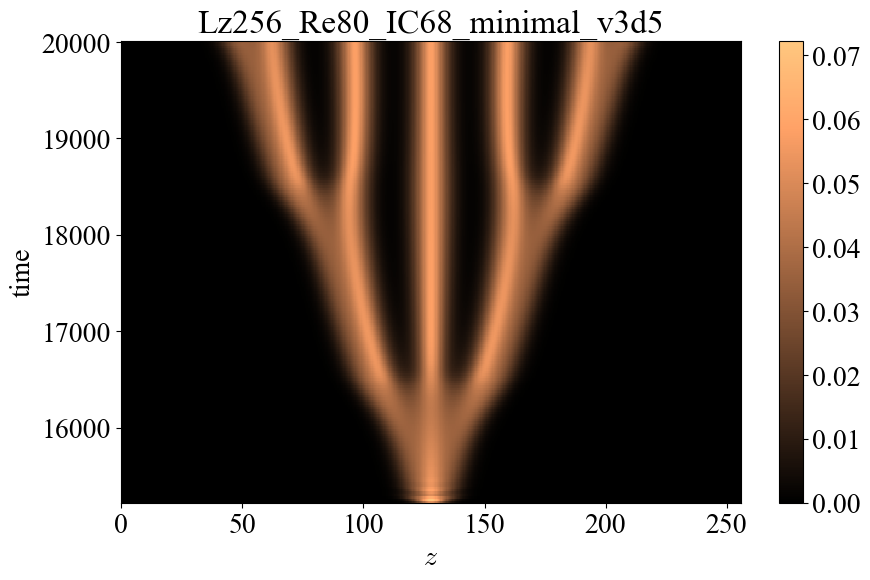

In [91]:
for run in runs[:]:
#     if '85' in run:
    try:
        plt.figure(figsize=(10,6))
        for ii,subdat in enumerate(data[run]):
            if ii==0:
                t = subdat['scales']['sim_time'][:]
                z = subdat['scales']['z']['1.0'][:]
                Lz = np.max(z)
                try:
                    dat = subdat['tasks']['q0'][:]
                except:
                    dat = subdat['tasks']['q'][:]
            else:
                t = np.concatenate((t,subdat['scales']['sim_time'][:]))
                try:
                    dat = np.concatenate((dat,subdat['tasks']['q0'][:]))
                except:
                    dat = np.concatenate((dat,subdat['tasks']['q'][:]))
        T,X = np.meshgrid(t,z,indexing='ij')
    #     T,X = np.meshgrid(np.arange(len(t[:])),z,indexing='ij')
        print('min',np.min(dat),np.where(dat[:]<-1e-6))
    #     plt.contourf(X,T,dat[:],vmin=0,vmax=np.max(dat[:]),cmap= cm.copper)
        plt.pcolormesh(X,T,dat[:],vmin=0,vmax=np.max(dat[t>50]),cmap= cm.copper)
        plt.colorbar()
        plt.xlabel(r"$z$",fontsize=20)
#         plt.ylim(0,400)
        plt.ylabel(r"time",fontsize=20)

#         xplt = np.linspace(128,256,1000)
#         v = 1/0.07#0.065
#         plt.plot(xplt,200+v*(xplt-130))

    #     plt.ylabel(r"output number",fontsize=20)
        plt.title(run)
        plt.savefig(odir+'turbulence.png',dpi=150,bbox_inches='tight')
        plt.show()
    except():
        print('hey')

# Snapshots

In [92]:
# Choose runs
# runs_snaps = [
# #     'Q0d5_sf' ,
# #     'Q1_sf' ,
# #     'Q2_sf' ,
#     'Q4_sf' ,
#     'Q8_sf' ,
#     'Q16_sf',
#     'Q4' ,
# ]
qs = []
ws = []
us = []
Res_plt = []
runs_snaps = np.copy(runs)
zlim = 256
plt.figure(figsize=(8,6))#2*size,size*(H/L)))
for run in runs_snaps[3:4]:
#     if '85' in run:
    n_max = data[run][-1]['scales']['write_number'][-1] # n_max is frame number, but with python we have to subtract one
    n = n_max#700#833
    s,n = snapshot_slice(n,data[run],'u0')

    # Read info:
    time = data[run][s]['scales']['sim_time'][n]
#         print(np.argmin(np.abs(data[run][s]['scales']['sim_time'][:]-5000)))

    # Define array for x and z axes
    Z = data[run][s]['scales']['z']['1.0'][:]
    Lz = np.max(Z)
    # Choose quantity to look at
    leg = {
        'u0':r"$u_0$",
        'u1':r"$u_1$",
        'v1':r"$v_1$",
        'w1':r"$w_1$",
        'zeta':r"$\zeta$",
        'q0':r"$q_0$",
        'q1':r"$q_1$",
    }
    fields = [
            'q0',
            'u0',
            'u1',
            'v1',
            'w1',
#             'q1',
#                     'zeta',
            ]


    size = 10
    # if 'Re68d0' in run:
    #     print('saving state for %s' % run)
    #     q0 = data[run][s]['tasks']['q0'][n,:]
    #     u0 = data[run][s]['tasks']['u0'][n,:]
    #     u1 = data[run][s]['tasks']['u1'][n,:]
    #     w1 = data[run][s]['tasks']['w1'][n,:]
    #     v1 = data[run][s]['tasks']['v1'][n,:]
    #     q1 = data[run][s]['tasks']['q1'][n,:]
    #     out = [Z,q0,u0,u1,v1,w1,q1]
    #     out = np.array(out,dtype=object)
    #     np.save('../state_'+run+'.npy',out)
    if (np.mean(data[run][s]['tasks']['q0'][n,:])>1e-7):
        plt.figure(figsize=(8,6))#2*size,size*(H/L)))

        for ii,field in enumerate(fields):
            # Plot!
            if field=='u1':
                dat = data[run][s]['tasks'][field][n,:] #+ np.cos(24/180*np.pi)
            elif field=='w1':
                dat = data[run][s]['tasks'][field][n,:] #+ np.sin(24/180*np.pi)
            if field=='q0':
                dat = data[run][s]['tasks'][field][n,:] #+ np.sin(24/180*np.pi)
                max_ind = np.argmax(dat)
                datshift = np.roll(dat,-max_ind)
                hw = Z[np.argmin(np.abs(datshift[:100]-np.max(datshift[:100])/2))]
                print('Half width',hw)
                xmin = Z[max_ind]
                xmax = xmin+hw
                plt.plot(Z[(Z<xmax)&(Z>xmin)],np.ones(Z[(Z<xmax)&(Z>xmin)].shape)*np.max(dat)/2,'--r')
            else:
                dat = data[run][s]['tasks'][field][n,:]
    #             if field=='q':
    #                 print('min',np.min(dat),np.where(dat[:]<0))

            print('at center %s = %.3e' % (field,dat[data[run][s]['tasks']['q0'][n,:]==np.max(data[run][s]['tasks']['q0'][n,:])]))
            print('max %s = %.3e' % (field,np.max(dat[Z<zlim])))
            print('min %s = %.3e' % (field,np.min(dat[Z<zlim])))
            Re = float(run.split('_')[1][2:].replace('d','.'))
    #             if Re>56:
            if field=='q0':
                Res_plt.append(Re)
                qs.append([np.mean(dat[:]),np.max(dat[:])])
            elif field=='w1':
                ws.append([np.mean(dat[:]),np.max(np.abs(dat[:]))])
            elif field=='u1':
                us.append([np.mean(dat[:]),np.max(np.abs(dat[:]))])
            plt.plot(Z,dat,label=leg[field])

        print('dz(u0) at center = %.2e' % (np.gradient(data[run][s]['tasks']['u0'][n,:],Z)[data[run][s]['tasks']['q0'][n,:]==np.max(data[run][s]['tasks']['q0'][n,:])]))
        plt.legend(loc=(1.01,0.01))
        plt.xlabel(r"$z$")
        plt.title(run+r' time = %f' % time,fontsize=15)
        # plt.ylim(-0.4,0.45)
        plt.xlim(32,256-32)
#         plt.xlim(128-10,128+10)
        plt.show()
    
#         Re = float(run.split('_')[1][2:].replace('d','.'))
#         aa1D.plot_YZ_xavg(time,Re,Z,Lz,u0,u1,v,w)

<Figure size 800x600 with 0 Axes>

# Extras
Budgets, and other things

In [93]:
# Choose runs
# runs_snaps = [
# #     'Q0d5_sf' ,
# #     'Q1_sf' ,
# #     'Q2_sf' ,
#     'Q4_sf' ,
#     'Q8_sf' ,
#     'Q16_sf',
#     'Q4' ,
# ]
qs = []
ws = []
us = []
Res_plt = []
runs_snaps = np.copy(runs)
zlim = 256
plt.figure(figsize=(8,6))#2*size,size*(H/L)))
for run in runs_snaps[3:4]:
#     if '85' in run:
    Re = float(run.split('_')[1][2:].replace('d','.'))
    Th_deg = float(run.split('_')[2][2:].replace('d','.'))
    alpha = 0.01
    theta = Th_deg/180*np.pi
    n_max = data[run][-1]['scales']['write_number'][-1] # n_max is frame number, but with python we have to subtract one
    n = n_max#700#833
    s,n = snapshot_slice(n,data[run],'u0')

    # Read info:
    time = data[run][s]['scales']['sim_time'][n]
#         print(np.argmin(np.abs(data[run][s]['scales']['sim_time'][:]-5000)))

    # Define array for x and z axes
    Z = data[run][s]['scales']['z']['1.0'][:]
    Lz = np.max(Z)
    # Choose quantity to look at
    leg = [
        r"$\partial_z (w_1(q_0)^2 \partial_z u_1)$",
        r"$w_1 \partial^2_z(w_1) u_1$",
        r"$\partial_z ((w_{lam}^2 + 2 w_{lam}w^\prime_1) \partial_z u_1)$",
        r"$w_{lam} \partial^2_z(w^\prime_1) u_1$",
    ]

    size = 10
    if (np.mean(data[run][s]['tasks']['q0'][n,:])>1e-7):
        # Load fields:
        ulam = np.cos(theta)
        wlam = np.sin(theta)
        q0 = data[run][s]['tasks']['q0'][n,:]
        u1 = data[run][s]['tasks']['u1'][n,:] + ulam
        w1 = data[run][s]['tasks']['w1'][n,:] + wlam

        # Calculate terms:
        terms = []
        terms.append(np.gradient((w1)**2*np.gradient(u1,Z),Z)/(2*3*alpha))
        terms.append(np.gradient(np.gradient(w1,Z),Z)*u1*w1/(2*3*alpha))
        terms.append(np.gradient(((wlam)**2+2*wlam*(w1-wlam))*np.gradient(u1,Z),Z)/(2*3*alpha))
        terms.append(np.gradient(np.gradient((w1-wlam),Z),Z)*u1*wlam/(2*3*alpha))
        
        plt.figure(figsize=(8,6))#2*size,size*(H/L)))
        for ii,term in enumerate(terms):
            plt.plot(Z,term,label=leg[ii],marker='',ls='-')

        plt.plot(Z,np.sum(terms[:2],axis=0),c='k',label='Total',ls='--')
        plt.plot(Z,np.sum(terms[2:],axis=0),c='k',label='Total reduced',ls='-.')
        # inds = np.where(np.abs(np.diff(np.sign(u1)))>0)[0]
        # plt.gca().axvspan(Z[inds[0]], Z[inds[1]], alpha=0.2, color='black',label=r'$u_1 > 0$')

        plt.axhline(y=0,color='k',ls='--',zorder=-1)

        plt.legend(loc=(1.01,0.01))
        plt.xlabel(r"$z$")
        plt.title(run+r' time = %f' % time,fontsize=15)
        plt.xlim(128-40,128+40)
        plt.savefig(odir+'u0_term_simple_reduced.png',dpi=150,bbox_inches='tight')
        plt.show()

<Figure size 800x600 with 0 Axes>

In [94]:
a*beta*0.05/(alpha+beta**2/Re)

TypeError: unsupported operand type(s) for /: 'float' and 'str'

In [ ]:
# Choose runs
# runs_snaps = [
# #     'Q0d5_sf' ,
# #     'Q1_sf' ,
# #     'Q2_sf' ,
#     'Q4_sf' ,
#     'Q8_sf' ,
#     'Q16_sf',
#     'Q4' ,
# ]
qs = []
ws = []
us = []
Res_plt = []
runs_snaps = np.copy(runs)
zlim = 256
plt.figure(figsize=(8,6))#2*size,size*(H/L)))
for run in runs_snaps[3:4]:
#     if '85' in run:
    Re = float(run.split('_')[1][2:].replace('d','.'))
    Th_deg = float(run.split('_')[2][2:].replace('d','.'))
    alpha = 0.01
    theta = Th_deg/180*np.pi
    n_max = data[run][-1]['scales']['write_number'][-1] # n_max is frame number, but with python we have to subtract one
    n = n_max#700#833
    s,n = snapshot_slice(n,data[run],'u0')

    # Read info:
    time = data[run][s]['scales']['sim_time'][n]
#         print(np.argmin(np.abs(data[run][s]['scales']['sim_time'][:]-5000)))

    # Define array for x and z axes
    Z = data[run][s]['scales']['z']['1.0'][:]
    Lz = np.max(Z)
    # Choose quantity to look at
    leg = [
        r"$\partial^2_z(w_1^2) u_1 /2$",
        r"$\frac{\beta^2 \sin^2 \theta}{2(\alpha+\beta^2/Re)^2}\partial_z^2 A(q_0)^2$",
        r"$-\frac{\beta \sin^2 \theta}{\alpha+\beta^2/Re}\partial_z^2 A(q_0)$",
        r"$-\frac{a \beta \sin^2 \theta}{\alpha+\beta^2/Re}\partial_z^2 q_0$",
        r"$-\frac{1}{2}\frac{a \beta \sin^2 \theta}{\alpha+\beta^2/Re}\partial_z^2 q_0$",
    ]

    size = 10
    if (np.mean(data[run][s]['tasks']['q0'][n,:])>1e-7):
        # Load fields:
        ulam = np.cos(theta)
        wlam = np.sin(theta)
        u1 = data[run][s]['tasks']['u1'][n,:] + ulam
        w1 = data[run][s]['tasks']['w1'][n,:] + wlam
        q0 = data[run][s]['tasks']['q0'][n,:]

        # Calculate terms:
        t1 = np.gradient(np.gradient(w1**2,Z),Z)*u1/2/(2*3*alpha) #*np.sign(u1)
        t2 = beta**2*np.sin(theta)**2*(2*(alpha+beta**2/Re)**2)**(-1)*np.gradient(np.gradient(A(q0,a,eta,Re)**2,Z),Z)*u1/(2*3*alpha) #*np.sign(u1)
        t3 = -beta*np.sin(theta)**2*(alpha+beta**2/Re)**(-1)*np.gradient(np.gradient(A(q0,a,eta,Re),Z),Z)*u1/(2*3*alpha) #*np.sign(u1)
        # t4 = -a*beta*np.sin(theta)**2*(alpha+beta**2/Re)**(-1)*np.gradient(np.gradient(q0,Z),Z)*u1/(2*3*alpha) #*np.sign(u1)
        # t5 = -a*beta*np.sin(theta)**2*(alpha+beta**2/Re)**(-1)*np.gradient(np.gradient(q0,Z),Z)*u1/(2*3*alpha)/2 #*np.sign(u1)
        
        
        plt.figure(figsize=(8,6))#2*size,size*(H/L)))
        for ii,term in enumerate([t1,t2,t3]):
            plt.plot(Z,term,label=leg[ii],marker='',ls='-')

        # plt.plot(Z,t2+t3,c='k',ls='--',label='Total')
        # inds = np.where(np.abs(np.diff(np.sign(u1)))>0)[0]
        # plt.gca().axvspan(Z[inds[0]], Z[inds[1]], alpha=0.2, color='black',label=r'$u_1 > 0$')

        plt.axhline(y=0,color='k',ls='--',zorder=-1)

        plt.legend(loc=(1.01,0.01))
        plt.xlabel(r"$z$")
        plt.title(run+r' time = %f' % time,fontsize=15)
        plt.xlim(128-40,128+40)
        plt.savefig(odir+'u0_third_term_simple.png',dpi=150,bbox_inches='tight')
        plt.show()

<Figure size 800x600 with 0 Axes>

In [ ]:
# Choose runs
# runs_snaps = [
# #     'Q0d5_sf' ,
# #     'Q1_sf' ,
# #     'Q2_sf' ,
#     'Q4_sf' ,
#     'Q8_sf' ,
#     'Q16_sf',
#     'Q4' ,
# ]
qs = []
ws = []
us = []
Res_plt = []
runs_snaps = np.copy(runs)
zlim = 256
plt.figure(figsize=(8,6))#2*size,size*(H/L)))
for run in runs_snaps[3:4]:
#     if '85' in run:
    Re = float(run.split('_')[1][2:].replace('d','.'))
    Th_deg = float(run.split('_')[2][2:].replace('d','.'))
    alpha = 0.01
    theta = Th_deg/180*np.pi
    n_max = data[run][-1]['scales']['write_number'][-1] # n_max is frame number, but with python we have to subtract one
    n = n_max#700#833
    s,n = snapshot_slice(n,data[run],'u0')

    # Read info:
    time = data[run][s]['scales']['sim_time'][n]
#         print(np.argmin(np.abs(data[run][s]['scales']['sim_time'][:]-5000)))

    # Define array for x and z axes
    Z = data[run][s]['scales']['z']['1.0'][:]
    Lz = np.max(Z)
    # Choose quantity to look at
    leg = [
        # r"$\partial^2_z(w_1^2) u_1 /2$",
        # r"$\frac{\beta^2 \sin^2 \theta}{2(\alpha+\beta^2/Re)^2}\partial_z^2 A(q_0)^2$",
        r"$-\frac{\beta \sin^2 \theta}{\alpha+\beta^2/Re}\partial_z^2 A(q_0)$",
        r"$-\frac{a \beta \sin^2 \theta}{\alpha+\beta^2/Re}\partial_z^2 q_0$",
        r"$-\frac{1}{2}\frac{a \beta \sin^2 \theta}{\alpha+\beta^2/Re}\partial_z^2 q_0$",
    ]

    size = 10
    if (np.mean(data[run][s]['tasks']['q0'][n,:])>1e-7):
        # Load fields:
        ulam = np.cos(theta)
        wlam = np.sin(theta)
        u1 = data[run][s]['tasks']['u1'][n,:] + ulam
        w1 = data[run][s]['tasks']['w1'][n,:] + wlam
        q0 = data[run][s]['tasks']['q0'][n,:]

        # Calculate terms:
        # t1 = np.gradient(np.gradient(w1**2,Z),Z)*u1/2/(2*3*alpha) #*np.sign(u1)
        t2 = beta**2*np.sin(theta)**2*(2*(alpha+beta**2/Re)**2)**(-1)*np.gradient(np.gradient(A(q0,a,eta,Re)**2,Z),Z)*u1/(2*3*alpha) #*np.sign(u1)
        t3 = -beta*np.sin(theta)**2*(alpha+beta**2/Re)**(-1)*np.gradient(np.gradient(A(q0,a,eta,Re),Z),Z)*u1/(2*3*alpha) #*np.sign(u1)
        t4 = -a*beta*np.sin(theta)**2*(alpha+beta**2/Re)**(-1)*np.gradient(np.gradient(q0,Z),Z)*u1/(2*3*alpha) #*np.sign(u1)
        t5 = -a*beta*np.sin(theta)**2*(alpha+beta**2/Re)**(-1)*np.gradient(np.gradient(q0,Z),Z)*u1/(2*3*alpha)/2 #*np.sign(u1)
        
        
        plt.figure(figsize=(8,6))#2*size,size*(H/L)))
        for ii,term in enumerate([t3,t4,t5]):
            plt.plot(Z,term,label=leg[ii],marker='',ls='-')

        plt.plot(Z,t2+t3,c='k',ls='--',label='Total')
        # inds = np.where(np.abs(np.diff(np.sign(u1)))>0)[0]
        # plt.gca().axvspan(Z[inds[0]], Z[inds[1]], alpha=0.2, color='black',label=r'$u_1 > 0$')

        plt.axhline(y=0,color='k',ls='--',zorder=-1)

        plt.legend(loc=(1.01,0.01))
        plt.xlabel(r"$z$")
        plt.title(run+r' time = %f' % time,fontsize=15)
        plt.xlim(128-40,128+40)
        # plt.savefig(odir+'u0_third_term_simple.png',dpi=150,bbox_inches='tight')
        plt.show()

<Figure size 800x600 with 0 Axes>

In [ ]:
np.where(np.abs(np.diff(np.sign(u1)))>0)

(array([509, 514]),)

In [ ]:
9400/3600

2.611111111111111